In [98]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## Purpose of the Code

Preprocesses raw ifo forecast data into analysis-ready time series:

- Load and clean data
-  Generate individual DataFrames and CSV files for each forecast vintage (Q4 2007 – Q4 2025)  
- Combine all nowcasts and one-step-ahead forecasts into a single structured DataFrame and export to CSV  
- Validate outputs by comparing nowcasts and one-step-ahead forecasts against realized values

In [99]:
# load data
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Benchmarks/Raw/Raw_ifo.csv',
                 delimiter=';',
                 decimal=',',
                 skiprows=2,
                 usecols=range(0,74))

df['Datenstand'] = pd.to_datetime(df['Datenstand'])
df['Datenstand'] = df['Datenstand'].dt.to_period('Q').dt.to_timestamp()
df = df.rename(columns={'Datenstand':'t'})

cols = pd.period_range(start='2007Q4', end='2025Q4', freq='Q').to_timestamp()
df.columns = ['t'] + list(cols)

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_47616/760939298.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datenstand'] = pd.to_datetime(df['Datenstand'])


In [100]:
# safe one csv-file for each forecast period
for c in df.columns[1:]:
    df_c = pd.DataFrame({
        't': df['t'],
        f'forecast_{c}': df[c]
    }).dropna()
    
    filename = f"/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Benchmarks/Preprocessed/ifo_forecast_{c.date()}.csv"
    
    df_c.to_csv(filename, index=False)

In [101]:
# safe one csv-file combining all nowcasts and one step forecasts
rows = []

for c in df.columns[1:]:
    mask = df['t'] == c
    
    if mask.any():
        idx = df.index[mask][0]
        
        val_t = df.loc[idx, c]
        val_t1 = df.loc[idx + 1, c] if idx + 1 in df.index else None
        
        rows.append({
            't': c,
            'nowcast': val_t,
            'one_step_forecast': val_t1
        })

consulidated_df = pd.DataFrame(rows)
consulidated_df = consulidated_df.dropna()

consulidated_df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Benchmarks/Preprocessed/ifo_forecast_all.csv', index=False)

<Axes: xlabel='t', ylabel='GDP_QoQ_change'>

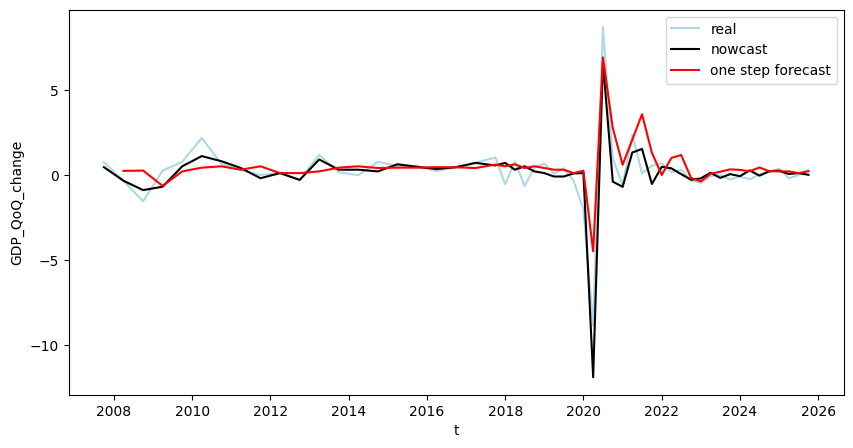

In [ ]:
# plot results against real data

# output validates code above. nowcast and one step forecast are close to real values

df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/GDP_QoQ_change.csv')
df['t'] = pd.to_datetime(df['t'])
consulidated_df = consulidated_df.merge(right=df, how='inner', on='t')
consulidated_df['forecast_aligned'] = consulidated_df['one_step_forecast'].shift(1)

plt.figure(figsize=(10,5))

sns.lineplot(data = consulidated_df, x = 't', y = 'GDP_QoQ_change', label = 'real', color = 'lightblue')
sns.lineplot(data = consulidated_df, x = 't', y = 'nowcast', label = 'nowcast', color = 'black')
sns.lineplot(data=consulidated_df, x='t', y='forecast_aligned', label='one step forecast', color = 'red')